# Verify DINOv2 Embeddings

Load images from `outputs/test_images/` and find matching embeddings.

In [1]:
import sys
sys.path.insert(0, '..')

import os
import json
import numpy as np
import torch
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt

print("Libraries loaded!")

Libraries loaded!


In [2]:
# ==================== CONFIG ====================

TEST_IMAGES_DIR = "../outputs/test_images"
TEST_EMBEDDINGS_PATH = "../dataset/nsd/embeddings_patches/dinov2_patches_test_sub01.npy"
TEST_IMAGE_IDS_PATH = "../dataset/nsd/embeddings_patches/image_ids_test_sub01.npy"
DATALIST_PATH = "../dataset/nsd/metadata/datalist_mindeye2_sub01.json"

# Indices to verify (from outputs/test_images/)
VERIFY_INDICES = [786, 694, 579, 541, 372, 271, 196, 32]

print(f"Indices to verify: {VERIFY_INDICES}")

Indices to verify: [786, 694, 579, 541, 372, 271, 196, 32]


In [3]:
# Load both orderings to understand the mapping

# 1. JSON datalist order (used for outputs/test_images/)
with open(DATALIST_PATH, 'r') as f:
    datalist = json.load(f)

json_test_nsd_ids = []
for nsd_id_str, nsd_data in datalist['samples'].items():
    if 'test' in nsd_data['splits']:
        json_test_nsd_ids.append(int(nsd_id_str))
json_test_nsd_ids = np.array(json_test_nsd_ids)

# 2. Embeddings order (from image_ids file)
emb_test_nsd_ids = np.load(TEST_IMAGE_IDS_PATH)

print(f"JSON order: {len(json_test_nsd_ids)} images")
print(f"Embeddings order: {len(emb_test_nsd_ids)} images")
print(f"\nFirst 5 JSON order NSD IDs: {json_test_nsd_ids[:5]}")
print(f"First 5 Emb order NSD IDs:  {emb_test_nsd_ids[:5]}")

# Create mapping: NSD ID -> embedding index
nsd_to_emb_idx = {nsd_id: idx for idx, nsd_id in enumerate(emb_test_nsd_ids)}

print(f"\nMapping created: {len(nsd_to_emb_idx)} NSD IDs")

JSON order: 982 images
Embeddings order: 982 images

First 5 JSON order NSD IDs: [46002 48617 44980 32625 53052]
First 5 Emb order NSD IDs:  [2950 2990 3049 3077 3146]

Mapping created: 982 NSD IDs


In [4]:
# Show the mapping for our indices
print("Index (test_images) -> NSD ID (JSON) -> Embedding Index")
print("-" * 55)

for idx in VERIFY_INDICES:
    nsd_id = json_test_nsd_ids[idx]
    emb_idx = nsd_to_emb_idx.get(nsd_id, -1)
    print(f"  {idx:4d} -> NSD {nsd_id:5d} -> emb_idx {emb_idx}")

Index (test_images) -> NSD ID (JSON) -> Embedding Index
-------------------------------------------------------
   786 -> NSD 22138 -> emb_idx 262
   694 -> NSD 10105 -> emb_idx 115
   579 -> NSD 25581 -> emb_idx 323
   541 -> NSD 64687 -> emb_idx 867
   372 -> NSD 17230 -> emb_idx 201
   271 -> NSD 58096 -> emb_idx 788
   196 -> NSD 34975 -> emb_idx 459
    32 -> NSD 71753 -> emb_idx 969


In [5]:
# Load dataset embeddings
dataset_embeddings = np.load(TEST_EMBEDDINGS_PATH)
print(f"Dataset embeddings shape: {dataset_embeddings.shape}")

Dataset embeddings shape: (982, 257, 768)


In [6]:
# Load DINOv2 model
embed_dim = dataset_embeddings.shape[-1]

if embed_dim == 384:
    model_name = 'dinov2_vits14'
elif embed_dim == 768:
    model_name = 'dinov2_vitb14'
elif embed_dim == 1024:
    model_name = 'dinov2_vitl14'
elif embed_dim == 1536:
    model_name = 'dinov2_vitg14'
else:
    raise ValueError(f"Unknown embedding dim: {embed_dim}")

print(f"Loading DINOv2 model: {model_name}...")
dinov2_model = torch.hub.load('facebookresearch/dinov2', model_name)
dinov2_model = dinov2_model.cuda().eval()

# DINOv2 preprocessing (224 -> 16x16 = 256 patches)
dinov2_transform = T.Compose([
    T.Resize(224, interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("DINOv2 model loaded!")

Loading DINOv2 model: dinov2_vitb14...


Using cache found in /home/sowwn/.cache/torch/hub/facebookresearch_dinov2_main
/home/sowwn/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/sowwn/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/sowwn/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2 model loaded!


In [7]:
def extract_dinov2_embedding(img_path, model, transform):
    """Extract CLS + patch tokens from image file using DINOv2."""
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).cuda()
    
    with torch.no_grad():
        output = model.forward_features(img_tensor)
        
        if isinstance(output, dict):
            cls_token = output['x_norm_clstoken']  # [1, dim]
            patch_tokens = output['x_norm_patchtokens']  # [1, N, dim]
            features = torch.cat([cls_token.unsqueeze(1), patch_tokens], dim=1)
        else:
            features = output
    
    return features.cpu().numpy()

print("Function defined!")

Function defined!


In [8]:
# Load images from outputs/test_images and extract embeddings
print("Loading images from outputs/test_images and extracting DINOv2 embeddings...\n")

extracted_embeddings = {}
images = {}

for idx in VERIFY_INDICES:
    img_path = os.path.join(TEST_IMAGES_DIR, f"{idx}.png")
    
    if os.path.exists(img_path):
        img = Image.open(img_path)
        images[idx] = np.array(img)
        
        emb = extract_dinov2_embedding(img_path, dinov2_model, dinov2_transform)
        extracted_embeddings[idx] = emb
        
        nsd_id = json_test_nsd_ids[idx]
        print(f"  Index {idx} (NSD {nsd_id}): extracted shape {emb.shape}")
    else:
        print(f"  Index {idx}: FILE NOT FOUND")

print("\nDone!")

Loading images from outputs/test_images and extracting DINOv2 embeddings...

  Index 786 (NSD 22138): extracted shape (1, 257, 768)
  Index 694 (NSD 10105): extracted shape (1, 257, 768)
  Index 579 (NSD 25581): extracted shape (1, 257, 768)
  Index 541 (NSD 64687): extracted shape (1, 257, 768)
  Index 372 (NSD 17230): extracted shape (1, 257, 768)
  Index 271 (NSD 58096): extracted shape (1, 257, 768)
  Index 196 (NSD 34975): extracted shape (1, 257, 768)
  Index 32 (NSD 71753): extracted shape (1, 257, 768)

Done!


In [9]:
# Verify using the correct mapping: JSON index -> NSD ID -> Embedding index
print("=" * 75)
print("VERIFICATION: Image (JSON order) -> NSD ID -> Embedding (emb order)")
print("=" * 75)
print(f"{'Img Idx':>7} | {'NSD ID':>6} | {'Emb Idx':>7} | {'CLS Cos':>10} | {'Status':>10}")
print("-" * 75)

MATCH_THRESHOLD = 0.9
results = []

for idx in VERIFY_INDICES:
    if idx not in extracted_embeddings:
        continue
        
    nsd_id = json_test_nsd_ids[idx]
    emb_idx = nsd_to_emb_idx.get(nsd_id, -1)
    
    if emb_idx == -1:
        print(f"{idx:>7} | {nsd_id:>6} | {'N/A':>7} | {'N/A':>10} | NOT FOUND")
        continue
    
    # Compare extracted embedding with dataset embedding at correct index
    extracted = extracted_embeddings[idx][0]  # [257, 768]
    dataset = dataset_embeddings[emb_idx]  # [257, 768]
    
    ext_cls = extracted[0]
    dat_cls = dataset[0]
    cls_cos = np.dot(ext_cls, dat_cls) / (np.linalg.norm(ext_cls) * np.linalg.norm(dat_cls))
    
    status = "MATCH" if cls_cos > MATCH_THRESHOLD else "MISMATCH"
    symbol = "[OK]" if cls_cos > MATCH_THRESHOLD else "[!!]"
    
    print(f"{idx:>7} | {nsd_id:>6} | {emb_idx:>7} | {cls_cos:>10.6f} | {symbol} {status}")
    
    results.append({
        'img_idx': idx,
        'nsd_id': nsd_id,
        'emb_idx': emb_idx,
        'cls_cosine': cls_cos,
        'match': cls_cos > MATCH_THRESHOLD
    })

print("=" * 75)
if results:
    mean_cls = np.mean([r['cls_cosine'] for r in results])
    print(f"Mean CLS cosine: {mean_cls:.6f}")
    
    all_match = all(r['match'] for r in results)
    if all_match:
        print("\nAll verified! Image <-> Embedding alignment is CORRECT.")
    else:
        print("\nWARNING: Some mismatches detected!")

VERIFICATION: Image (JSON order) -> NSD ID -> Embedding (emb order)
Img Idx | NSD ID | Emb Idx |    CLS Cos |     Status
---------------------------------------------------------------------------
    786 |  22138 |     262 |   0.960047 | [OK] MATCH
    694 |  10105 |     115 |   0.975388 | [OK] MATCH
    579 |  25581 |     323 |   0.970367 | [OK] MATCH
    541 |  64687 |     867 |   0.971886 | [OK] MATCH
    372 |  17230 |     201 |   0.961108 | [OK] MATCH
    271 |  58096 |     788 |   0.984474 | [OK] MATCH
    196 |  34975 |     459 |   0.881222 | [!!] MISMATCH
     32 |  71753 |     969 |   0.972130 | [OK] MATCH
Mean CLS cosine: 0.959578



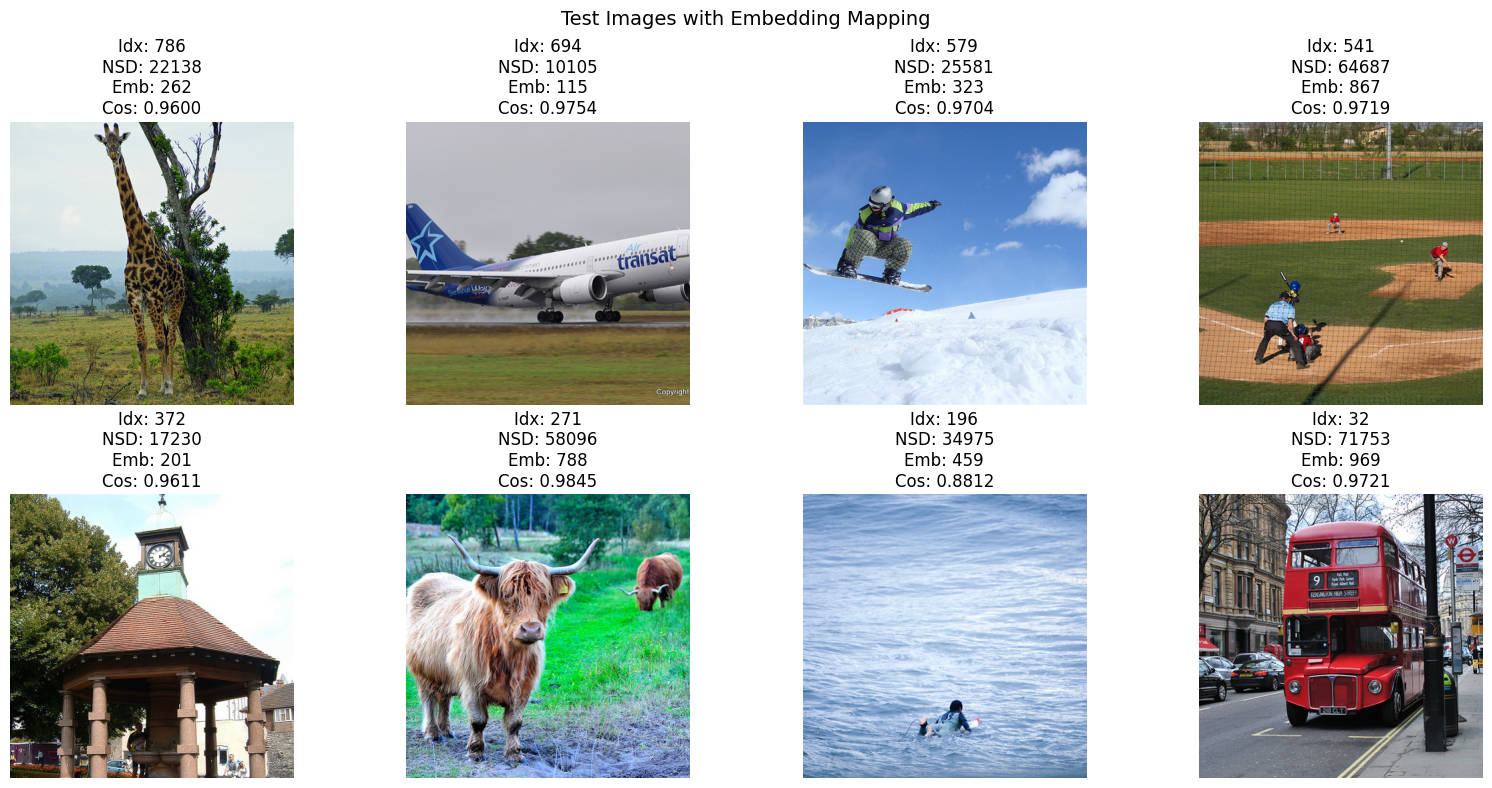

In [10]:
# Visualize images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, idx in enumerate(VERIFY_INDICES):
    ax = axes[i // 4, i % 4]
    if idx in images:
        ax.imshow(images[idx])
        nsd_id = json_test_nsd_ids[idx]
        emb_idx = nsd_to_emb_idx.get(nsd_id, -1)
        if results and i < len(results):
            cos = results[i]['cls_cosine']
            ax.set_title(f"Idx: {idx}\nNSD: {nsd_id}\nEmb: {emb_idx}\nCos: {cos:.4f}")
        else:
            ax.set_title(f"Idx: {idx}\nNSD: {nsd_id}\nEmb: {emb_idx}")
    else:
        ax.text(0.5, 0.5, f"Not found: {idx}", ha='center', va='center')
    ax.axis('off')

plt.suptitle("Test Images with Embedding Mapping", fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
# Cleanup
del dinov2_model
torch.cuda.empty_cache()
print("DINOv2 model unloaded.")

DINOv2 model unloaded.
